## Бизнес-задача

AutoValue AI нужен алгоритм мгновенной оценки подержанных автомобилей для автоматического выкупа. Ошибка модели напрямую влияет на деньги:

- завысили цену - риск купить авто дороже рынка и получить убыток;
- занизили цену - клиент уйдёт к конкурентам;
- долго считаем - клиент закрывает приложение.

Цель проекта — выбрать лучшую ML-библиотеку для оценки стоимости авто: `CatBoost`, `LightGBM` или `XGBoost`.

## ML-постановка

Задача — регрессия.

Целевой признак:

`price_rub` — рыночная стоимость автомобиля в рублях.

Основная метрика:

`MAE`, потому что она показывает среднюю ошибку в рублях и понятна бизнесу.

Дополнительные метрики:

- `RMSE` - контроль крупных ошибок;
- `R²` - общее качество объяснения цены;
- `Overpricing Rate` - доля опасных переплат, когда прогноз выше реальности более чем на 20%;
- `Underpricing Loss` - сумма потерь, когда прогноз ниже реальности более чем на 20%;
- время обучения и предсказания.

## Данные

Используются два файла:

- `ds_s16_train_data.csv` - 8 000 сделок для EDA, обучения, валидации и Optuna-тюнинга;
- `ds_s16_test_data.csv` - 2 000 объектов только для финальной проверки.

## Первичные гипотезы

1. Влияние пробега нелинейное.
   Пробег до определённого порога может снижать цену умеренно, но после условных 100–150 тыс. км эффект должен усиливаться. Для старых автомобилей высокий пробег может быть менее критичен, чем для свежих.

2. Количество владельцев важно с возрастом авто.
   4–5 владельцев для старого автомобиля могут быть нормой, но такое же значение для свежей машины — сильный сигнал риска и возможных скрытых проблем.

3. ДТП по-разному влияет на цену в разных ценовых сегментах.
   Для массовых бюджетных авто небольшое ДТП может быть менее критичным, а для дорогих или премиальных брендов даже один accident_reported может резко снижать цену и ликвидность. При этом для более качественной оценки важно понимать степень серьезности дтп

4. Регион может менять не только базовый уровень цены, но и важность признаков.
   Например, в одних регионах больше ценится автоматическая коробка, в других — экономичный двигатель или низкая стоимость обслуживания. Поэтому `region` может работать как модификатор спроса.

5. Сервисная история сильнее влияет на цену дорогих и свежих автомобилей.
   Для старых бюджетных машин наличие сервисной книжки может давать слабый эффект, но для свежих авто без сервисной истории модель должна снижать оценку заметнее.

6. Цвет может влиять не на стоимость, а на ликвидность.
   Популярные цвета могут не сильно повышать цену напрямую, но должны снижать риск недооценки спроса. Редкие цвета могут давать больший разброс ошибок. Возможно в данном случае после проведения моделирования имеет смысл дать бизнесу обратную связь: взять в работу стабильный рынок с определенными характеристиками (выявленными по shap и ошибкам модели), например не брать редкие цвета или определенные регионы

7 Для разных сегментов рынка может требоваться разная стратегия ошибки.

   Массовые автомобили и премиальные автомобили имеют разную цену ошибки. На дешёвом массовом авто переплата может быть ограниченной, а на дорогом автомобиле одна ошибка может перекрыть прибыль от десятков успешных сделок.

   Гипотеза: единая модель с одной глобальной функцией потерь может быть недостаточно эффективна. Лучше оценивать качество отдельно по ценовым сегментам и, возможно, использовать разные уровни осторожности для разных групп автомобилей.
    Проверкой станет: разбиение автомобилей на ценовые сегменты: бюджетный, средний, дорогой;
   - посчитать MAE, относительную ошибку, `Overpricing Rate` и `Underpricing Loss` внутри каждого сегмента;
   - проверить, не “компенсируется” ли хорошее качество на массовом сегменте плохим качеством на дорогих авто;
   - сравнить обычную модель и риск-скорректированную модель внутри каждого сегмента.

   Если гипотеза подтвердится, бизнесу стоит внедрять разные правила оффера для разных сегментов: более агрессивную оценку для ликвидных массовых авто и более консервативную для дорогих или нестабильных сегментов. То есть выделить несколько моделей по сегментам, с разными порогами предсказания


## План работы

1. Загрузить данные и проверить качество датасета.
2. Провести EDA: `price_rub`, пропуски, дубликаты, корреляции, категории.
3. Подготовить единое `train/valid`-разбиение.
4. Реализовать стандартные и бизнес-метрики.
5. Обучить baseline: CatBoost, LightGBM, XGBoost.
6. Провести Optuna-тюнинг по заданным диапазонам.
7. Сравнить модели в общей таблице.
8. Провести SHAP-анализ топ-3 моделей.
9. Проверить ошибки по `brand`  `region` и ценовому сегменту.
10. протестировать CatBoost Quantile Regression.
11. Выбрать финальную модель.
12. Один раз оценить её на `ds_s16_test_data.csv`.

In [37]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone


from catboost import Pool
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

import phik

import optuna
from optuna.visualization import plot_optimization_history

import shap


rs = 42
ts = 0.2

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [2]:
try:
    train = pd.read_csv('ds_s16_train_data.csv')
    test = pd.read_csv('ds_s16_test_data.csv')

except FileNotFoundError as e:
    df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_train_data.csv')
    df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s16_test_data.csv')
data = {
    'train ': train,
    'test': test,
}

for name, df in data.items():
    print('=' * 70)
    print(f'{name}: {df.shape}')
    print('=' * 70)

train : (8000, 13)
test: (2000, 13)


In [3]:
 for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(pd.concat([df.head(), df.tail(), df.sample(5)]))

========== train  ==========


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь
7995,2000,17.84,5000,Petrol,1,Hyundai,Manual,White,Unknown,0,No,993550,Москва
7996,1999,26.62,1800,Petrol,3,Kia,Manual,Gray,Full,2,Yes,487962,Сибирь
7997,2009,23.90,3000,Diesel,5,Volkswagen,Manual,White,Full,0,Yes,808630,Урал
7998,2016,14.06,1500,Diesel,1,Tesla,Automatic,White,Full,0,Yes,642222,Москва
7999,1998,20.54,1200,Diesel,1,Volkswagen,Manual,Gray,Unknown,0,Yes,622646,Дальний Восток


========== test ==========


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб
1995,2008,16.51,2500,Petrol,4,Tesla,Automatic,Gray,Full,0,Yes,629476,Москва
1996,2010,12.17,1500,Petrol,2,Toyota,Manual,White,Full,0,Yes,517497,Урал
1997,2014,14.93,5000,Electric,5,Chevrolet,Manual,Red,Unknown,0,Yes,1248892,Сибирь
1998,2016,14.63,1000,Electric,1,Volkswagen,Manual,Gray,Full,0,No,1083834,Москва
1999,2000,17.90,1500,Diesel,5,Kia,Manual,Silver,Unknown,0,Yes,472599,Москва


In [4]:
def eda(df):
    eda_cols = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True)
    }).reset_index().rename(columns={'index': 'column'})
    display(eda_cols)
eda(train)

,column,dtype,nulls,null_pct,nunique
0,make_year,int64,0,0.00,29
1,mileage_kmpl,float64,0,0.00,2108
2,engine_cc,int64,0,0.00,10
3,fuel_type,object,0,0.00,3
4,owner_count,int64,0,0.00,5
5,brand,object,0,0.00,10
6,transmission,object,0,0.00,2
7,color,object,0,0.00,6
8,service_history,object,0,0.00,3
9,accidents_reported,int64,0,0.00,6


In [5]:
def split_features_by_type(df, target):
    cat_cols = (
        df
        .select_dtypes(include=["object", "category"])
        .columns
        .difference([target])
        .tolist()
    )
    num_cat_cols = []
    candidate_cols = df.columns.difference([target] + cat_cols)
    for col in candidate_cols:
        if df[col].nunique() < 10:
            num_cat_cols.append(col)
    num_cols = (
        df
        .select_dtypes(include=["number"])
        .columns
        .difference([target])
        .difference(num_cat_cols)
        .tolist()
    )


    return cat_cols, num_cols, num_cat_cols
target = "price_rub"
cat_cols, num_cols, num_cat_cols = split_features_by_type(train, target)
print(f"Всего признаков: {len(train.columns)}")
display(f"Категориальные: {len(cat_cols)}, Числовые {len(num_cols)} Числовые категориальные  {len(num_cat_cols)}")
all_cols = cat_cols + num_cols + num_cat_cols
display(f"Разница: {train.columns.difference(all_cols)}")

Всего признаков: 13


'Категориальные: 7, Числовые 3 Числовые категориальные  2'

"Разница: Index(['price_rub'], dtype='object')"

In [6]:
for name, df in data.items():
    df[cat_cols] = df[cat_cols].astype('category')
    print(df[cat_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   brand            8000 non-null   category
 1   color            8000 non-null   category
 2   fuel_type        8000 non-null   category
 3   insurance_valid  8000 non-null   category
 4   region           8000 non-null   category
 5   service_history  8000 non-null   category
 6   transmission     8000 non-null   category
dtypes: category(7)
memory usage: 56.1 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   brand            2000 non-null   category
 1   color            2000 non-null   category
 2   fuel_type        2000 non-null   category
 3   insurance_valid  2000 non-null   category
 4   region           2000 non-null 

In [7]:
def graphics_numerical(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

def graphics_numerical_cat(df, column):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[column])
    plt.title(F"Распределение признака {column}")
    plt.xlabel("Уникальные значения")
    plt.ylabel("Количество")
    plt.show()

    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values)

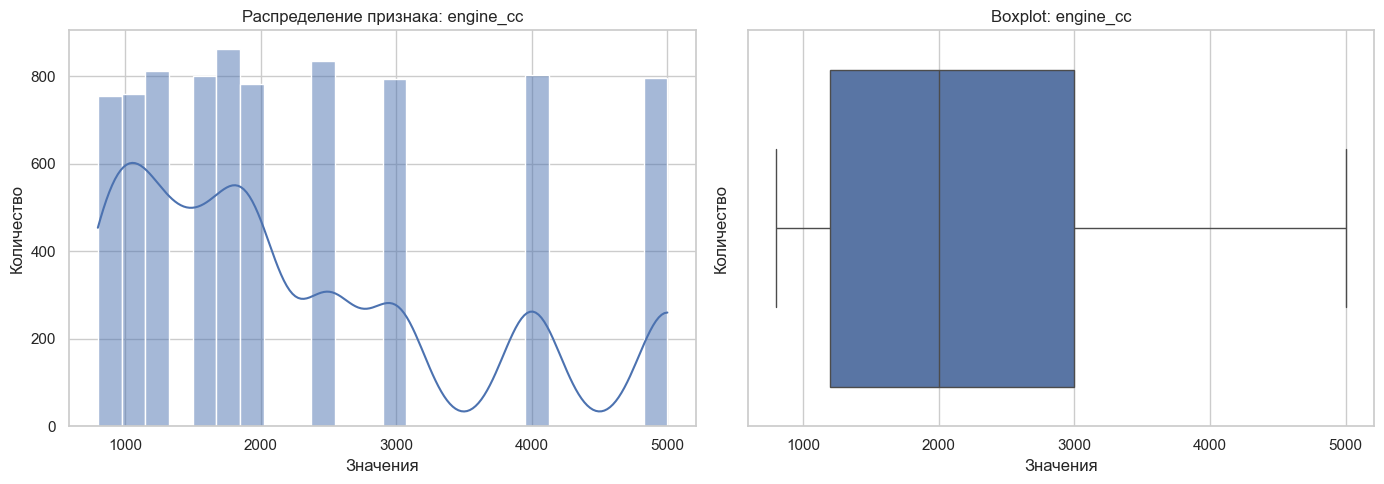

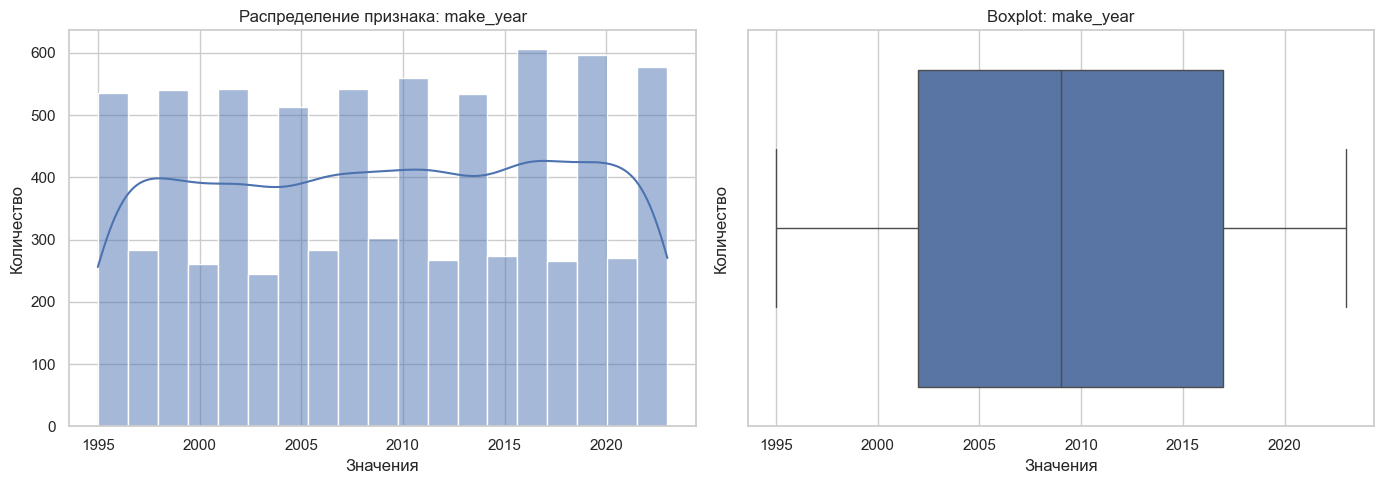

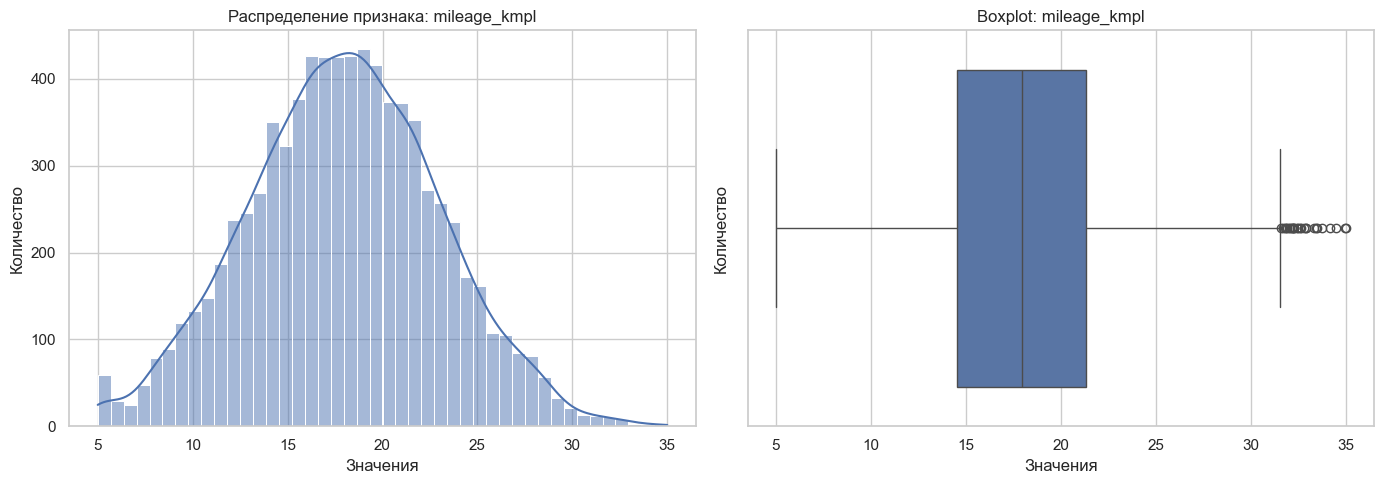

In [8]:
for col in num_cols:
    graphics_numerical(train, col)

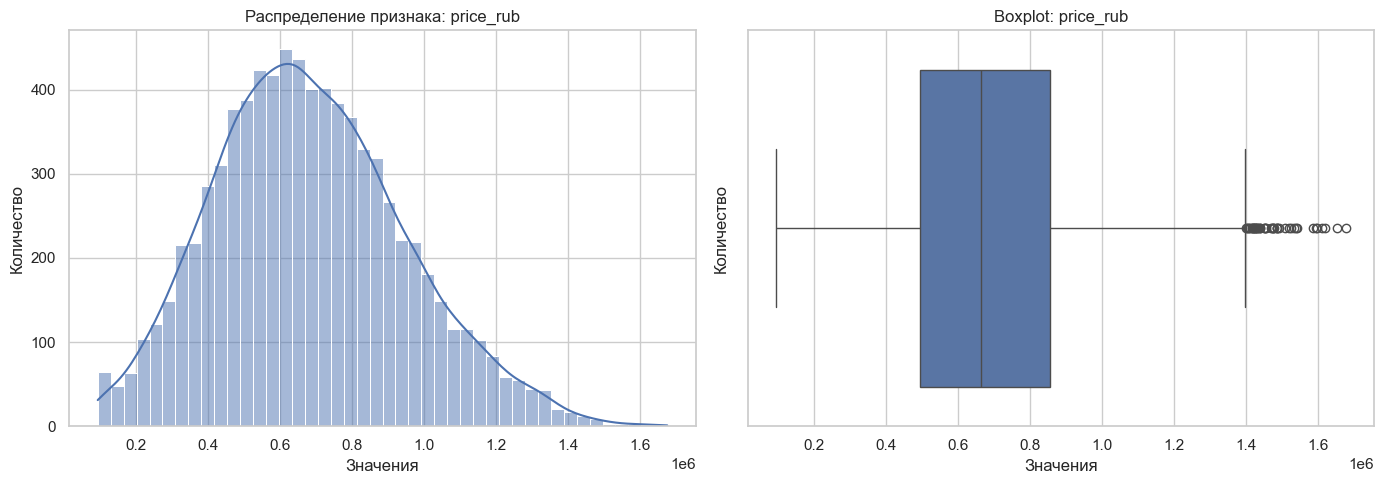

In [9]:
graphics_numerical(train, target)

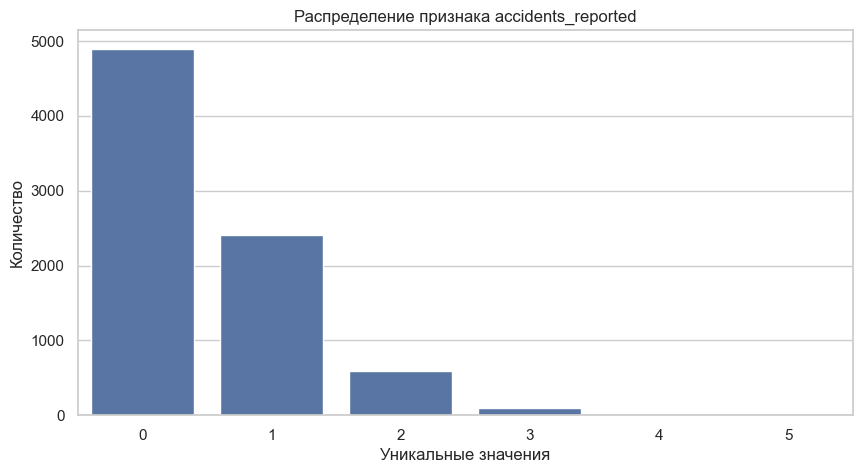

Распределение accidents_reported, количество и доля


,Количество,Доля
accidents_reported,,
0,4898,0.61
1,2414,0.30
2,585,0.07
3,95,0.01
4,6,0.00
5,2,0.00


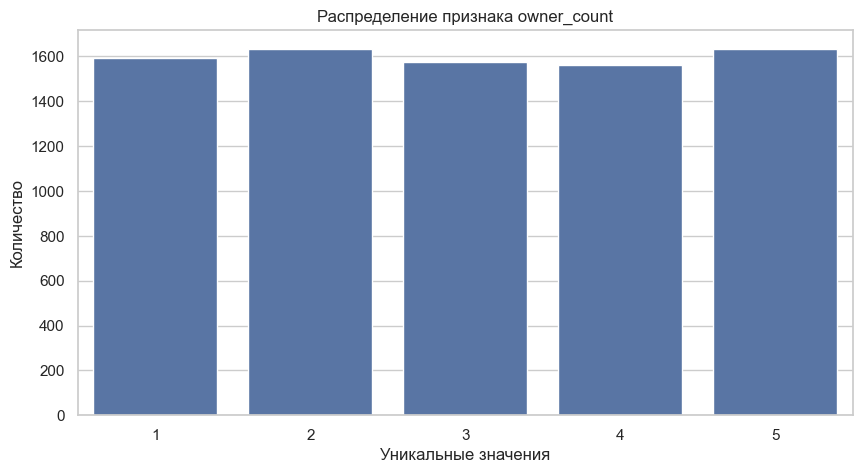

Распределение owner_count, количество и доля


,Количество,Доля
owner_count,,
5,1635,0.20
2,1634,0.20
1,1594,0.20
3,1576,0.20
4,1561,0.20


In [10]:
for col in num_cat_cols:
    graphics_numerical_cat(train, col)

['make_year', 'mileage_kmpl', 'engine_cc', 'price_rub']


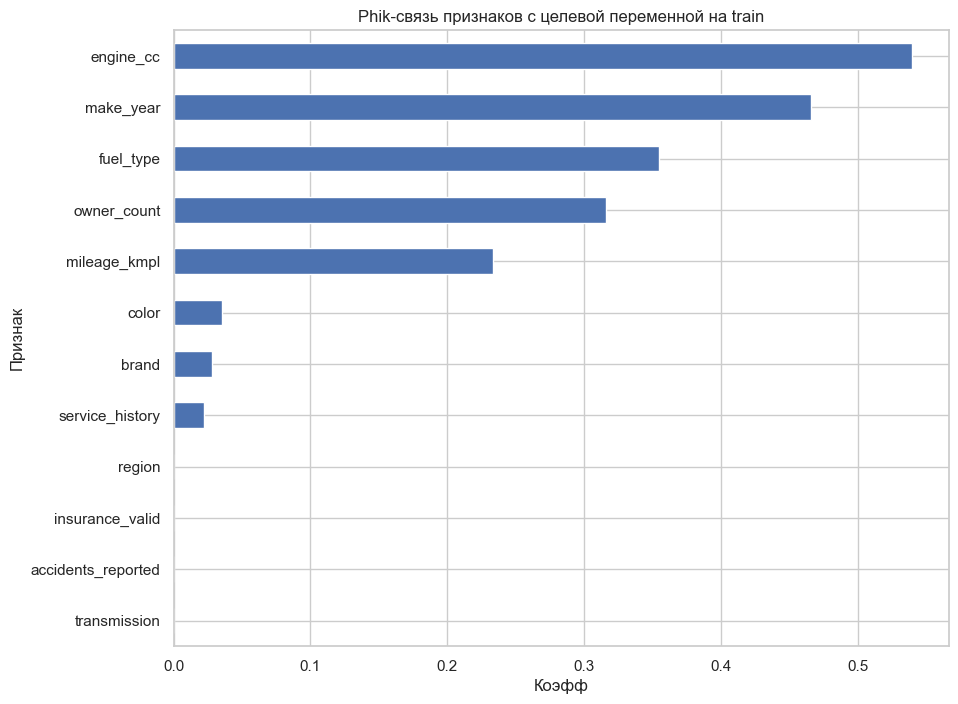

,phik_with_target
engine_cc,0.54
make_year,0.47
fuel_type,0.35
owner_count,0.32
mileage_kmpl,0.23
color,0.04
brand,0.03
service_history,0.02
transmission,0.00
accidents_reported,0.00


In [11]:
phik_data = train.copy()

interval_cols = [
    col for col in phik_data.select_dtypes(include="number").columns
    if col not in num_cat_cols
]
print(interval_cols)
phik_corr = phik_data.phik_matrix(interval_cols=interval_cols)
target_phik = (
    phik_corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))
target_phik.sort_values().plot(kind="barh")
plt.title("Phik-связь признаков с целевой переменной на train")
plt.xlabel("Коэфф")
plt.ylabel("Признак")
plt.show()

display(target_phik.to_frame("phik_with_target"))

In [12]:
for col in ["brand", "region", "transmission", "fuel_type"]:
    display(
        train
        .groupby(col)[target]
        .agg(["count", "mean", "median"])
        .sort_values("median", ascending=False)
    )

/var/folders/jv/jv9x_2q51k30nvslr16nk8gh0000gn/T/ipykernel_25741/3148020349.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)[target]


,count,mean,median
brand,,,
BMW,827,"692,037.24","678,124.00"
Ford,742,"699,378.44","678,090.50"
Honda,804,"690,464.14","676,352.50"
Nissan,870,"675,254.08","668,361.00"
Volkswagen,831,"687,765.87","666,482.00"
Toyota,792,"675,790.80","663,090.00"
Chevrolet,800,"691,261.16","661,910.50"
Kia,765,"677,657.63","654,129.00"
Tesla,784,"672,272.05","650,532.50"


/var/folders/jv/jv9x_2q51k30nvslr16nk8gh0000gn/T/ipykernel_25741/3148020349.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)[target]


,count,mean,median
region,,,
Юг,1408,"689,465.92","669,221.00"
СПб,1346,"686,690.13","667,138.00"
Урал,1371,"685,678.72","665,710.00"
Дальний Восток,1295,"679,099.07","663,348.00"
Москва,1319,"675,013.64","659,440.00"
Сибирь,1261,"685,399.08","658,250.00"


/var/folders/jv/jv9x_2q51k30nvslr16nk8gh0000gn/T/ipykernel_25741/3148020349.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)[target]


,count,mean,median
transmission,,,
Automatic,3188,"686,031.71","666,395.00"
Manual,4812,"682,068.55","662,782.00"


/var/folders/jv/jv9x_2q51k30nvslr16nk8gh0000gn/T/ipykernel_25741/3148020349.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(col)[target]


,count,mean,median
fuel_type,,,
Electric,797,"928,178.34","912,343.00"
Diesel,3213,"657,953.64","645,799.00"
Petrol,3990,"655,493.68","635,569.50"


**Вывод по EDA:** обучающая выборка содержит 8 000 строк и 13 колонок, финальная тестовая выборка — 2 000 строк. Пропусков в train нет, поэтому отдельная стратегия imputing здесь не требуется. Целевая переменная `price_rub` варьируется примерно от 95 тыс. до 1,68 млн руб., медиана — около 664 тыс. руб.; такой разброс делает RMSE важным индикатором крупных промахов. По PhiK сильнее всего с ценой связаны `engine_cc`, `make_year`, `fuel_type`, `owner_count` и `mileage_kmpl`, а `brand`, `region`, `transmission`, `insurance_valid` и `accidents_reported` по отдельности дают слабый сигнал. При этом таблицы групп показывают заметную разницу по `fuel_type`: электромобили имеют существенно более высокую медианную цену, чем Diesel и Petrol.


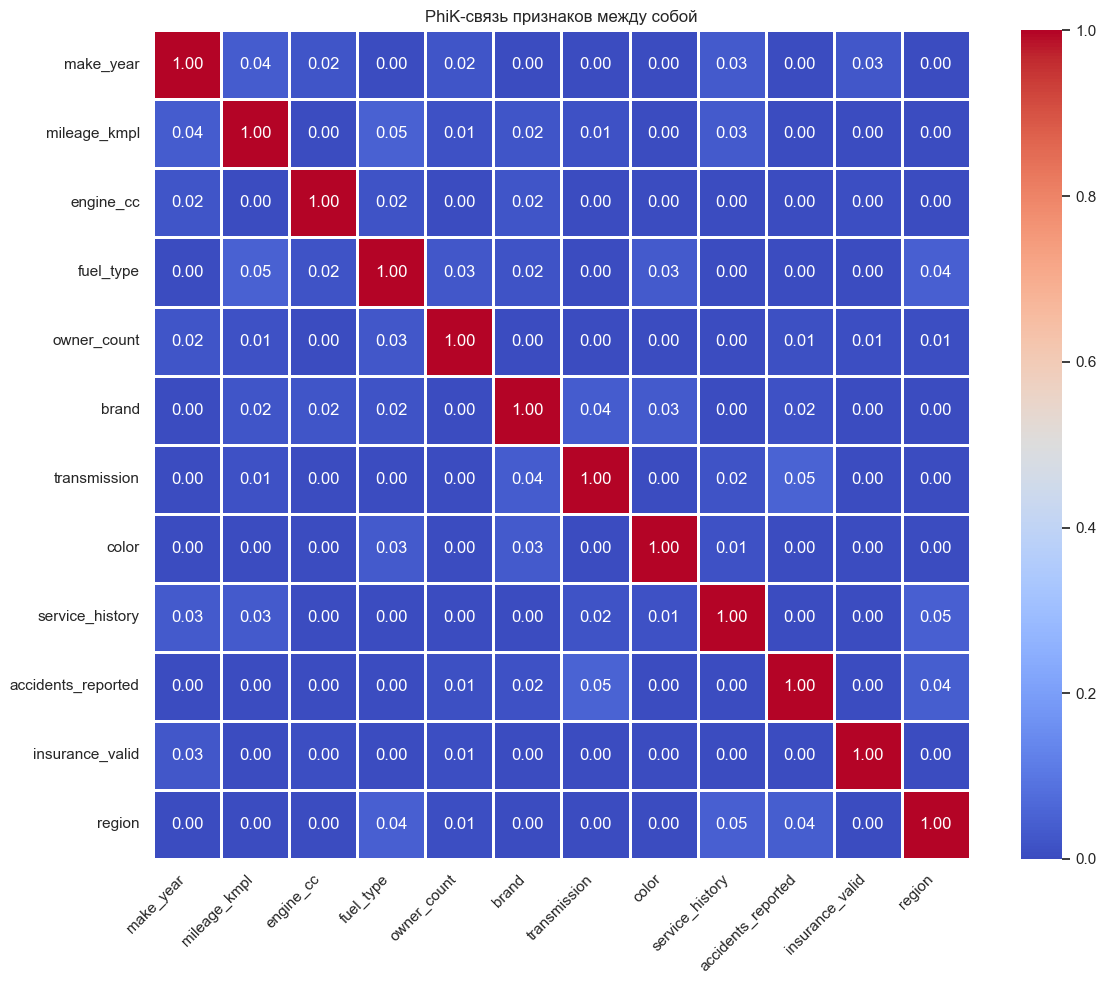

In [13]:
phik_features = phik_corr.drop(
    index=target,
    columns=target
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    phik_features,
    cmap="coolwarm",
    linewidths=1.0,
    cbar=True,
    annot=True,
    fmt=".2f"
)

plt.title("PhiK-связь признаков между собой")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [14]:
class AutoFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, actual_year=2026):
        self.actual_year = actual_year
        self.brand_popularity_ = {}
        self.median_mileage_ = {}
        self.global_median_mileage_ = 0

    def fit(self, X, y=None):
        self.brand_popularity_ = X['brand'].value_counts().to_dict()
        self.median_mileage_ = X.groupby('make_year')['mileage_kmpl'].median().to_dict()
        self.global_median_mileage_ = X['mileage_kmpl'].median()

        return self

    def transform(self, X):
        X = X.copy()
        X["age_auto"] = self.actual_year - X["make_year"]
        safe_age = X["age_auto"] + 1
        X["intensive_explore"] = X["mileage_kmpl"] / safe_age
        X["intensive_owner"] = safe_age / X["owner_count"]
        X["accidents_per_year"] = X["accidents_reported"] / safe_age
        X["years_between_accidents"] = X["age_auto"] / (X["accidents_reported"] + 1)
        X["brand_popularity"] = (X["brand"].astype("object").map(self.brand_popularity_).fillna(0))
        mapped_medians = X['make_year'].map(self.median_mileage_).fillna(self.global_median_mileage_)
        X["std_mileage"] = X["mileage_kmpl"] - mapped_medians
        X["pseudo_model"] = X["brand"].astype(str) + "_" + X["engine_cc"].astype(str) + "_" + X["transmission"].astype(str)
        X["is_perfect_condition"] = ((X["accidents_reported"] == 0) &
                             (X["service_history"].astype(str) == "Full") &
                             (X["owner_count"] <= 2)).astype(int)
        X["region_brand"] = X["region"].astype(str) + "_" + X["brand"].astype(str)
        X["region_fuel"] = X["region"].astype(str) + "_" + X["fuel_type"].astype(str)
        cat_features_new = [
            "pseudo_model",
            "region_brand",
            "region_fuel"]


        for col in cat_features_new:
            X[col] = X[col].astype("category")

        return X


In [15]:
X_train = train.drop(columns=[target])
y_train = train[target]
print(X_train.shape)
print(y_train.shape)

(8000, 12)
(8000,)


In [16]:
all_scores_df = pd.DataFrame()
cv = KFold(n_splits=5, shuffle=True, random_state=rs)

def evaluate_model_cv(estimator, model_name, X, y, cv_splitter, threshold=0.20):
    start = time.time()
    oof_preds = cross_val_predict(estimator, X, y, cv=cv_splitter, n_jobs=-1)
    y_array = np.array(y)

    mae = mean_absolute_error(y_array, oof_preds)
    rmse = np.sqrt(mean_squared_error(y_array, oof_preds))
    r2 = r2_score(y_array, oof_preds)

    error_ratio = (oof_preds - y_array) / y_array

    overpricing_rate = np.mean(error_ratio > threshold) * 100

    under_mask = error_ratio < -threshold
    underpricing_loss = np.sum(y_array[under_mask] - oof_preds[under_mask])

    duration = time.time() - start

    results_df = pd.DataFrame({
        'Model': [model_name],
        'time_fit': [round(duration, 4)],
        'MAE': [mae],
        'RMSE': [rmse],
        'R2': [r2],
        'Overpricing Rate, %': [overpricing_rate],
        'Underpricing Loss, руб.': [underpricing_loss]
    })
    return results_df

In [17]:
cat_cols_feature = cat_cols + [
    "pseudo_model",
    "region_brand",
    "region_fuel"
]
cat_base = CatBoostRegressor(
    cat_features=tuple(cat_cols),
    verbose=0,
    random_seed=rs
)
lgb_base = LGBMRegressor(
    random_state=rs,
    verbose=-1,
    n_jobs=-1,
    categorical_feature=cat_cols,
)
xgb_base = XGBRegressor(
    enable_categorical=True,
    random_state=rs,
    n_jobs=-1
)
cat_base_feature = CatBoostRegressor(
    cat_features=tuple(cat_cols_feature),
    verbose=0,
    random_seed=rs
)
base_cat_feature = Pipeline(steps=[
    ("feature_engine", AutoFeatureEngineer()),
    ("model", cat_base_feature)
])
base_lgb_feature = Pipeline(steps=[
    ("feature_engine", AutoFeatureEngineer()),
    ("model", lgb_base)
])
base_xgb_feature = Pipeline(steps=[
    ("feature_engine", AutoFeatureEngineer()),
    ("model", xgb_base)
])
base_models = {
    "lgb_base": lgb_base,
    "cat_base": cat_base,
    "xgb_base": xgb_base,
    "base_cat_feature": base_cat_feature,
    "base_lgb_feature": base_lgb_feature,
    "base_xgb_feature": base_xgb_feature
}


In [18]:
for name, model in base_models.items():
    result = evaluate_model_cv(model, name, X_train, y_train, cv, threshold=0.20)
    all_scores_df = pd.concat([all_scores_df, result], ignore_index=True)
    display(result)

/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
/Users/avera

,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,lgb_base,2.18,"78,977.74","99,256.65",0.86,14.46,"89,842,162.23"


,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,cat_base,6.77,"76,971.15","96,648.37",0.87,13.88,"83,183,603.49"


,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,xgb_base,0.49,"85,554.18","107,456.24",0.84,15.46,"120,584,730.18"


,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,base_cat_feature,11.46,"77,163.02","96,907.11",0.87,13.50,"83,324,057.09"


/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
/Users/average/Desktop/учеба/.venv/lib/python3.14/site-packages/lightgbm/basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
/Users/avera

,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,base_lgb_feature,2.01,"80,916.16","101,851.32",0.85,14.20,"102,001,712.62"


,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,base_xgb_feature,0.41,"97,167.55","122,769.20",0.79,17.15,"181,622,912.62"


In [19]:
display(all_scores_df.sort_values(by="Overpricing Rate, %", ascending=True))

,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
3,base_cat_feature,11.46,"77,163.02","96,907.11",0.87,13.50,"83,324,057.09"
1,cat_base,6.77,"76,971.15","96,648.37",0.87,13.88,"83,183,603.49"
4,base_lgb_feature,2.01,"80,916.16","101,851.32",0.85,14.20,"102,001,712.62"
0,lgb_base,2.18,"78,977.74","99,256.65",0.86,14.46,"89,842,162.23"
2,xgb_base,0.49,"85,554.18","107,456.24",0.84,15.46,"120,584,730.18"
5,base_xgb_feature,0.41,"97,167.55","122,769.20",0.79,17.15,"181,622,912.62"


**Вывод по baseline-турниру:** среди базовых моделей лучший баланс показывает CatBoost: `cat_base` имеет минимальный MAE 76,971 руб., RMSE 96,648 руб. и R² 0.87. LightGBM немного уступает по MAE и RMSE, а XGBoost в базовой настройке заметно слабее и по стандартным метрикам, и по бизнес-рискам. Добавленные признаки улучшают Overpricing Rate у CatBoost до 13.50%, но почти не улучшают MAE и увеличивают время обучения; для LightGBM и XGBoost feature engineering ухудшает качество, значит часть новых признаков может быть шумной для этих библиотек. RMSE стабильно выше MAE, поэтому в данных есть отдельные крупные ошибки, которые важны для финансового риска.


In [20]:
quantile_scores_df = pd.DataFrame()

for alpha in [0.1, 0.2, 0.3, 0.4]:
    model = CatBoostRegressor(
        loss_function=f"Quantile:alpha={alpha}",
        cat_features=tuple(cat_cols),
        verbose=0,
        random_seed=rs
    )

    result = evaluate_model_cv(
        model,
        f"cat_quantile_{alpha}",
        X_train,
        y_train,
        cv,
        threshold=0.20
    )

    quantile_scores_df = pd.concat(
        [quantile_scores_df, result],
        ignore_index=True
    )

display(
    pd.concat(
        [all_scores_df, quantile_scores_df],
        ignore_index=True
    )
    .sort_values("Overpricing Rate, %")
)

,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
6,cat_quantile_0.1,6.11,"127,655.73","152,082.24",0.67,2.12,"650,203,592.54"
7,cat_quantile_0.2,6.34,"100,592.10","123,839.42",0.78,4.65,"373,513,960.15"
8,cat_quantile_0.3,6.82,"86,213.48","107,896.66",0.83,7.46,"225,398,965.11"
9,cat_quantile_0.4,6.84,"78,938.97","99,196.81",0.86,10.08,"135,406,989.73"
3,base_cat_feature,11.46,"77,163.02","96,907.11",0.87,13.50,"83,324,057.09"
1,cat_base,6.77,"76,971.15","96,648.37",0.87,13.88,"83,183,603.49"
4,base_lgb_feature,2.01,"80,916.16","101,851.32",0.85,14.20,"102,001,712.62"
0,lgb_base,2.18,"78,977.74","99,256.65",0.86,14.46,"89,842,162.23"
2,xgb_base,0.49,"85,554.18","107,456.24",0.84,15.46,"120,584,730.18"
5,base_xgb_feature,0.41,"97,167.55","122,769.20",0.79,17.15,"181,622,912.62"


**Интерпретация quantile-моделей:** уменьшение `alpha` у CatBoost резко снижает Overpricing Rate, но цена этого снижения — рост MAE и Underpricing Loss. Например, `cat_quantile_0.4` снижает Overpricing Rate до 10.08%, но увеличивает Underpricing Loss до 135.4 млн руб.; при `alpha=0.1` завышений почти нет, зато потери от занижения становятся чрезмерными. Для бизнеса это прямой компромисс: меньше риск купить автомобиль слишком дорого, но выше риск предложить клиенту слишком низкую цену

In [21]:
optuna_typing = pd.DataFrame()

In [22]:
"""
def objective_cat(trial):
    params = {
        "loss_function": "MAE",
        "eval_metric": "MAE",
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_seed": rs,
        "verbose": 0,
        "cat_features": tuple(cat_cols),
    }

    model = CatBoostRegressor(**params)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores["test_score"].mean()


study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective_cat, n_trials=20)

metrics_optuna = pd.DataFrame({
    "Модель": ["Catboost_alpha0.4"],
    "Лучший MAE": [study_cat.best_value],
    "Лучшие параметры": [study_cat.best_params],
})

optuna_typing = pd.concat(
    [optuna_typing, metrics_optuna],
    ignore_index=True
)

print("Best MAE:", study_cat.best_value)
print("Best params:", study_cat.best_params)
"""

'\ndef objective_cat(trial):\n    params = {\n        "loss_function": "MAE",\n        "eval_metric": "MAE",\n        "iterations": trial.suggest_int("iterations", 500, 2000),\n        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),\n        "depth": trial.suggest_int("depth", 3, 10),\n        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),\n        "random_seed": rs,\n        "verbose": 0,\n        "cat_features": tuple(cat_cols),\n    }\n\n    model = CatBoostRegressor(**params)\n\n    scores = cross_validate(\n        model,\n        X_train,\n        y_train,\n        cv=cv,\n        scoring="neg_mean_absolute_error",\n        n_jobs=-1\n    )\n\n    return -scores["test_score"].mean()\n\n\nstudy_cat = optuna.create_study(direction="minimize")\nstudy_cat.optimize(objective_cat, n_trials=20)\n\nmetrics_optuna = pd.DataFrame({\n    "Модель": ["Catboost_alpha0.4"],\n    "Лучший MAE": [study_cat.best_value],\n    "Лучшие параметры": [study_cat.best

**Optuna / CatBoost:** лучший validation MAE в поиске — 78,824 руб. для параметров `iterations=1154`, `learning_rate=0.0241`, `depth=3`, `l2_leaf_reg=6.68`. Небольшая глубина дерева указывает, что для этого датасета лучше работает умеренно простая модель, а не глубокие деревья с высоким риском переобучения.


In [23]:
#fig = plot_optimization_history(study_cat)
#fig.show()

In [24]:
"""
def objective_lgbm(trial):
    params = {
        "objective": "mae",
        "metric": "mae",
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "random_state": rs,
        "verbose": -1,
        "n_jobs": -1,
    }

    model = LGBMRegressor(**params)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores["test_score"].mean()


study_lgbm = optuna.create_study(direction="minimize")
study_lgbm.optimize(objective_lgbm, n_trials=20)

metrics_optuna = pd.DataFrame({
    "Модель": ["LGBM"],
    "Лучший MAE": [study_lgbm.best_value],
    "Лучшие параметры": [study_lgbm.best_params],
})

optuna_typing = pd.concat(
    [optuna_typing, metrics_optuna],
    ignore_index=True
)

print("Best MAE:", study_lgbm.best_value)
print("Best params:", study_lgbm.best_params)

[I 2026-06-13 20:14:32,480] A new study created in memory with name: no-name-23b4729a-abcc-4894-a680-96d0ee751788
[I 2026-06-13 20:14:43,828] Trial 0 finished with value: 79782.90339821964 and parameters: {'n_estimators': 1200, 'learning_rate': 0.08369386441471455, 'max_depth': 5, 'num_leaves': 246, 'min_child_samples': 9, 'reg_alpha': 0.5415756066375903, 'reg_lambda': 0.00019122022348486443}. Best is trial 0 with value: 79782.90339821964.
[I 2026-06-13 20:15:52,847] Trial 1 finished with value: 80057.48181129304 and parameters: {'n_estimators': 1478, 'learning_rate': 0.026517616584751758, 'max_depth': 10, 'num_leaves': 98, 'min_child_samples': 5, 'reg_alpha': 3.7886472686349793e-07, 'reg_lambda': 0.8475814612364638}. Best is trial 0 with value: 79782.90339821964.
[I 2026-06-13 20:16:04,329] Trial 2 finished with value: 80000.97111455828 and parameters: {'n_estimators': 877, 'learning_rate': 0.07758145649681149, 'max_depth': 6, 'num_leaves': 159, 'min_child_samples': 48, 'reg_alpha': 0

Best MAE: 77426.39211579369
Best params: {'n_estimators': 2000, 'learning_rate': 0.010295411129813817, 'max_depth': 3, 'num_leaves': 107, 'min_child_samples': 99, 'reg_alpha': 0.013482774814619396, 'reg_lambda': 4.686593985987041e-06}


**Optuna / LightGBM:** лучший MAE — 77,426 руб. при `n_estimators=2000`, `learning_rate=0.0103`, `max_depth=3`, `num_leaves=107`, `min_child_samples=99`. Поиск также выбрал неглубокие деревья и низкий learning rate, то есть качество достигается за счет большого числа осторожных шагов.


In [25]:
#fig = plot_optimization_history(study_lgbm)
#fig.show()

In [31]:
"""
def objective_xgb(trial):
    params = {
        "objective": "reg:absoluteerror",
        "eval_metric": "mae",

        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "enable_categorical": True,
        "random_state": rs,
        "verbosity": 0,
        "n_jobs": -1,
    }

    model = XGBRegressor(**params)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores["test_score"].mean()

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=20)

metrics_optuna = pd.DataFrame({
    "Модель": ["XGB"],
    "Лучший MAE": [study_xgb.best_value],
    "Лучшие параметры": [study_xgb.best_params],
})

optuna_typing = pd.concat(
    [optuna_typing, metrics_optuna],
    ignore_index=True
)

print("Best MAE:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

[I 2026-06-13 20:29:42,114] A new study created in memory with name: no-name-a19cab48-7bab-47a8-acb4-74a65fd7e00d
[I 2026-06-13 20:29:47,384] Trial 0 finished with value: 78804.5046875 and parameters: {'n_estimators': 1177, 'learning_rate': 0.030278075350233483, 'max_depth': 5, 'gamma': 0.11782168003408736, 'reg_alpha': 2.5289550791343864e-07, 'reg_lambda': 0.00390829136771647}. Best is trial 0 with value: 78804.5046875.
[I 2026-06-13 20:29:52,062] Trial 1 finished with value: 81943.209375 and parameters: {'n_estimators': 557, 'learning_rate': 0.0789517564513309, 'max_depth': 9, 'gamma': 3.778895912388085e-08, 'reg_alpha': 3.4702313762236354, 'reg_lambda': 0.04016685341195427}. Best is trial 0 with value: 78804.5046875.
[I 2026-06-13 20:29:59,329] Trial 2 finished with value: 81626.675 and parameters: {'n_estimators': 1800, 'learning_rate': 0.041827744881333666, 'max_depth': 9, 'gamma': 1.6307172505884836e-07, 'reg_alpha': 4.602561767184681e-08, 'reg_lambda': 0.20911937419958498}. Best

Best MAE: 77374.9375
Best params: {'n_estimators': 1218, 'learning_rate': 0.015191772640814335, 'max_depth': 3, 'gamma': 0.0015843946346500695, 'reg_alpha': 7.110418866900772e-06, 'reg_lambda': 1.4805741834477446e-05}


**Optuna / XGBoost:** лучший MAE — 77,375 руб. при `n_estimators=1218`, `learning_rate=0.0152`, `max_depth=3`. После настройки XGBoost почти догнал LightGBM, но в итоговой таблице все еще уступает CatBoost по стандартным метрикам и не дает преимущества по Overpricing Rate.


In [27]:
#fig = plot_optimization_history(study_xgb)
#fig.show()

In [34]:
cat_best_params = {
    "iterations": 1154,
    "learning_rate": 0.024125471099492743,
    "depth": 3,
    "l2_leaf_reg": 6.680570270177146,
}

lgbm_best_params = {
    "n_estimators": 2000,
    "learning_rate": 0.010295411129813817,
    "max_depth": 3,
    "num_leaves": 107,
    "min_child_samples": 99,
    "reg_alpha": 0.013482774814619396,
    "reg_lambda": 4.686593985987041e-06,
}

xgb_best_params = {
    "n_estimators": 1218,
    "learning_rate": 0.015191772640814335,
    "max_depth": 3,
    "gamma": 0.0015843946346500695,
    "reg_alpha": 7.110418866900772e-06,
    "reg_lambda": 1.4805741834477446e-05,
}


optuna_models = {
    "cat_optuna": CatBoostRegressor(
        **cat_best_params,
        loss_function="MAE",
        eval_metric="MAE",
        cat_features=tuple(cat_cols),
        random_seed=rs,
        verbose=0,
    ),
    "cat_optuna_quantile": CatBoostRegressor(
        **cat_best_params,
        loss_function=f"Quantile:alpha=0.4",
        eval_metric="MAE",
        cat_features=tuple(cat_cols),
        random_seed=rs,
        verbose=0,
    ),

    "lgbm_optuna": LGBMRegressor(
        **lgbm_best_params,
        objective="mae",
        metric="mae",
        random_state=rs,
        verbose=-1,
        n_jobs=-1,
    ),

    "xgb_optuna": XGBRegressor(
        **xgb_best_params,
        objective="reg:absoluteerror",
        eval_metric="mae",
        enable_categorical=True,
        random_state=rs,
        verbosity=0,
        n_jobs=-1,
    ),
}

In [35]:
tuned_scores_df = pd.DataFrame()

for name, model in optuna_models.items():
    result = evaluate_model_cv(
        model,
        name,
        X_train,
        y_train,
        cv,
        threshold=0.20
    )

    tuned_scores_df = pd.concat(
        [tuned_scores_df, result],
        ignore_index=True
    )

all_scores_full_df = pd.concat(
    [
        all_scores_df,
        quantile_scores_df,
        tuned_scores_df
    ],
    ignore_index=True
)

display(
    all_scores_full_df
    .sort_values(["MAE", "Overpricing Rate, %"])
    .reset_index(drop=True)
)

,Model,time_fit,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,cat_optuna,4.19,"76,410.37","95,960.70",0.87,13.69,"77,593,039.94"
1,cat_base,6.77,"76,971.15","96,648.37",0.87,13.88,"83,183,603.49"
2,base_cat_feature,11.46,"77,163.02","96,907.11",0.87,13.50,"83,324,057.09"
3,xgb_optuna,2.57,"77,374.94","97,343.74",0.86,13.75,"81,719,019.85"
4,lgbm_optuna,7.51,"77,426.39","97,493.18",0.86,13.91,"82,744,340.94"
5,cat_optuna_quantile,4.07,"78,823.99","99,051.53",0.86,9.99,"134,867,210.08"
6,cat_quantile_0.4,6.84,"78,938.97","99,196.81",0.86,10.08,"135,406,989.73"
7,lgb_base,2.18,"78,977.74","99,256.65",0.86,14.46,"89,842,162.23"
8,base_lgb_feature,2.01,"80,916.16","101,851.32",0.85,14.20,"102,001,712.62"
9,xgb_base,0.49,"85,554.18","107,456.24",0.84,15.46,"120,584,730.18"


**Вывод после Optuna:** тюнинг улучшил все основные библиотеки, но лучший MAE на кросс-валидации получил `cat_optuna` — 76,410 руб. при RMSE 95,961 руб. и R² 0.87. XGBoost и LightGBM после настройки стали близки друг к другу, но остаются чуть слабее CatBoost по MAE/RMSE. По бизнес-метрикам картина меняется: `cat_optuna_quantile` имеет более высокий MAE 78,824 руб., зато снижает Overpricing Rate до 9.99%, что заметно безопаснее для сценария автоматического выкупа. Поэтому финальный выбор зависит не только от точности, но и от того, какой риск AutoValue AI считает более дорогим: переплата при покупке или потеря части сделок из-за занижения цены.


SHAP-анализ модели: cat_optuna


,Model,feature,mean_abs_shap
0,cat_optuna,engine_cc,"145,462.08"
1,cat_optuna,make_year,"101,874.21"
2,cat_optuna,owner_count,"51,852.64"
3,cat_optuna,fuel_type,"50,585.37"
4,cat_optuna,mileage_kmpl,"44,442.01"


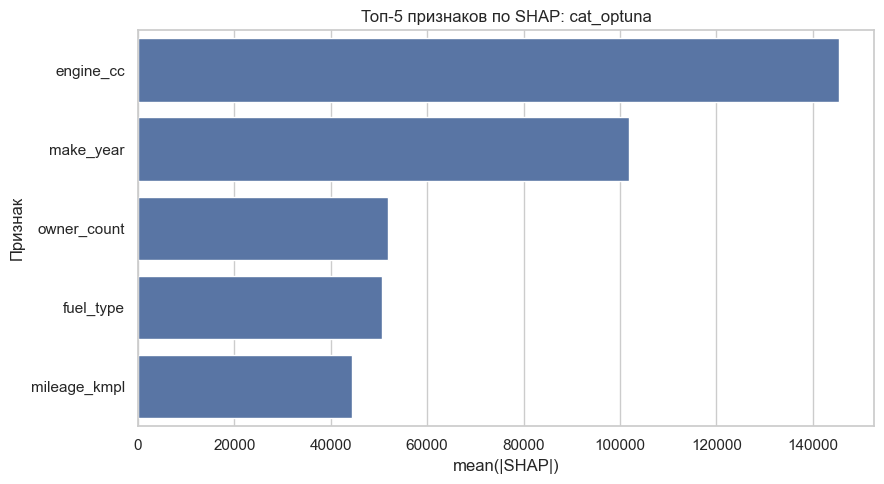

SHAP-анализ модели: cat_optuna_quantile


,Model,feature,mean_abs_shap
0,cat_optuna_quantile,engine_cc,"144,876.27"
1,cat_optuna_quantile,make_year,"101,663.48"
2,cat_optuna_quantile,owner_count,"51,685.18"
3,cat_optuna_quantile,fuel_type,"50,756.50"
4,cat_optuna_quantile,mileage_kmpl,"45,617.01"


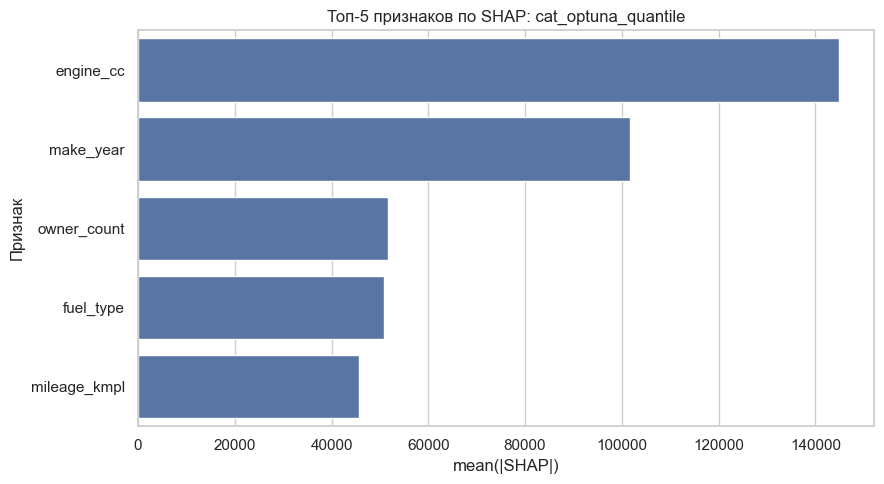

SHAP-анализ модели: lgbm_optuna


,Model,feature,mean_abs_shap
0,lgbm_optuna,engine_cc,"143,359.11"
1,lgbm_optuna,make_year,"102,239.89"
2,lgbm_optuna,owner_count,"51,976.39"
3,lgbm_optuna,fuel_type,"50,947.41"
4,lgbm_optuna,mileage_kmpl,"44,919.73"


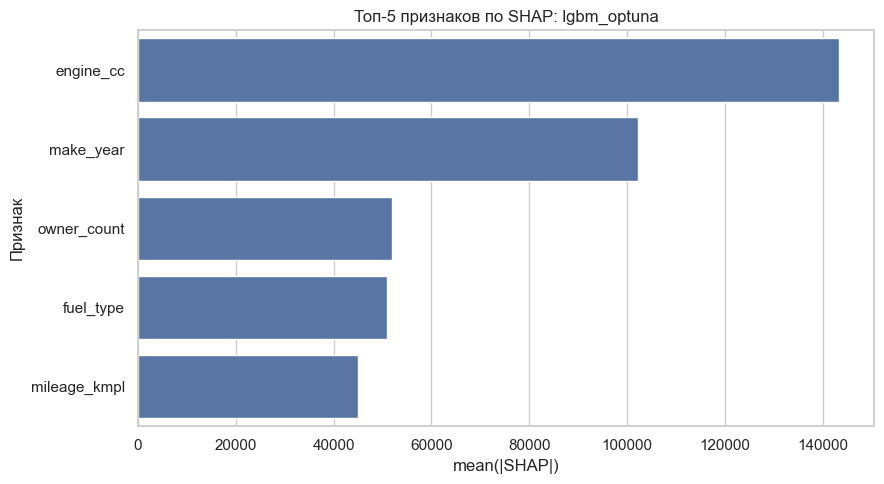

SHAP-анализ модели: xgb_optuna


,Model,feature,mean_abs_shap
0,xgb_optuna,engine_cc,"143,493.19"
1,xgb_optuna,make_year,"102,285.80"
2,xgb_optuna,owner_count,"51,444.76"
3,xgb_optuna,fuel_type,"50,490.48"
4,xgb_optuna,mileage_kmpl,"44,758.09"


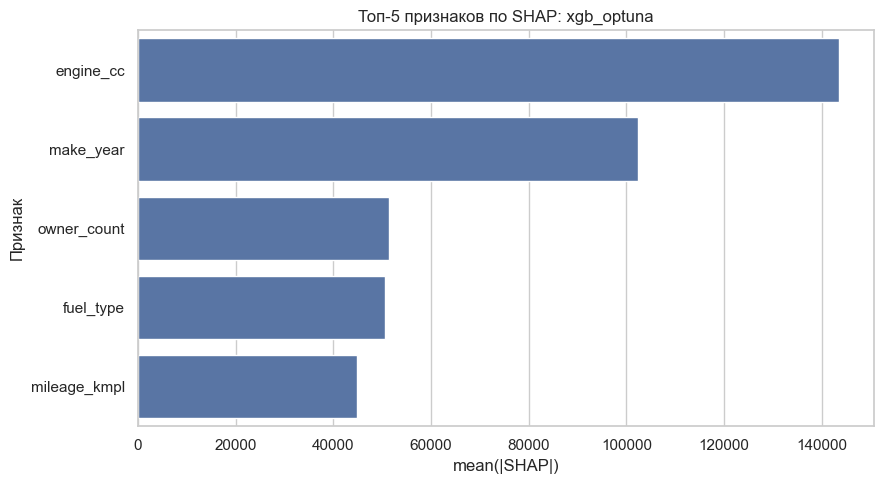

In [38]:
X_shap = X_train.sample(
    min(1000, len(X_train)),
    random_state=rs
)

shap_top_features_df = pd.DataFrame()

for name, model in optuna_models.items():
    print("=" * 80)
    print(f"SHAP-анализ модели: {name}")
    print("=" * 80)

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    if name == "cat_optuna":
        shap_values = fitted_model.get_feature_importance(
            Pool(X_shap, cat_features=cat_cols),
            type="ShapValues"
        )[:, :-1]

    else:
        explainer = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_shap)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

    model_shap_importance = (
        pd.DataFrame({
            "Model": name,
            "feature": X_shap.columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0)
        })
        .sort_values("mean_abs_shap", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    shap_top_features_df = pd.concat(
        [shap_top_features_df, model_shap_importance],
        ignore_index=True
    )

    display(model_shap_importance)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=model_shap_importance,
        x="mean_abs_shap",
        y="feature"
    )
    plt.title(f"Топ-5 признаков по SHAP: {name}")
    plt.xlabel("mean(|SHAP|)")
    plt.ylabel("Признак")
    plt.tight_layout()
    plt.show()

SHAP summary plot: cat_optuna


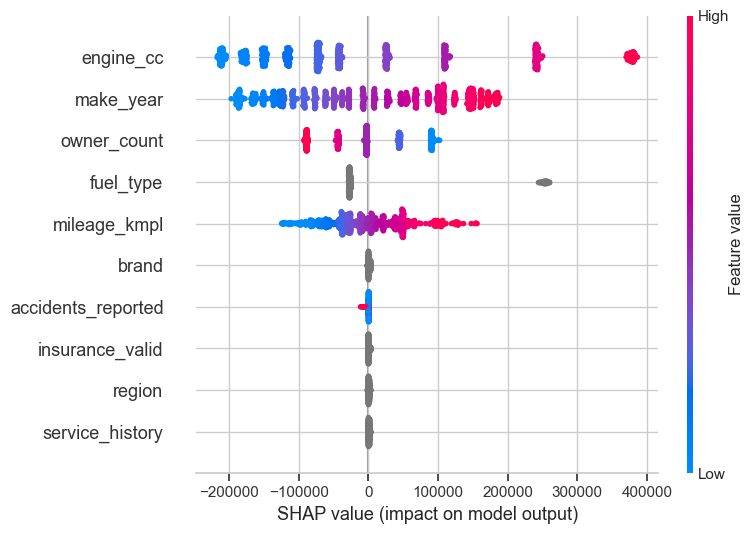

SHAP summary plot: cat_optuna_quantile


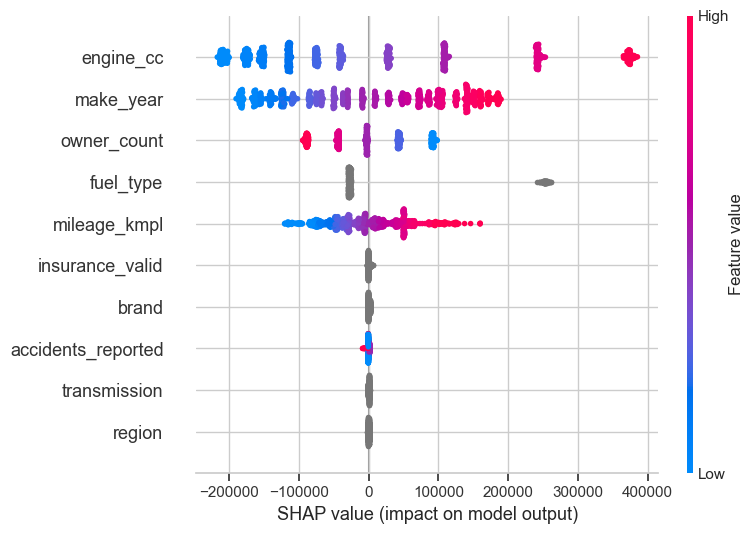

SHAP summary plot: lgbm_optuna


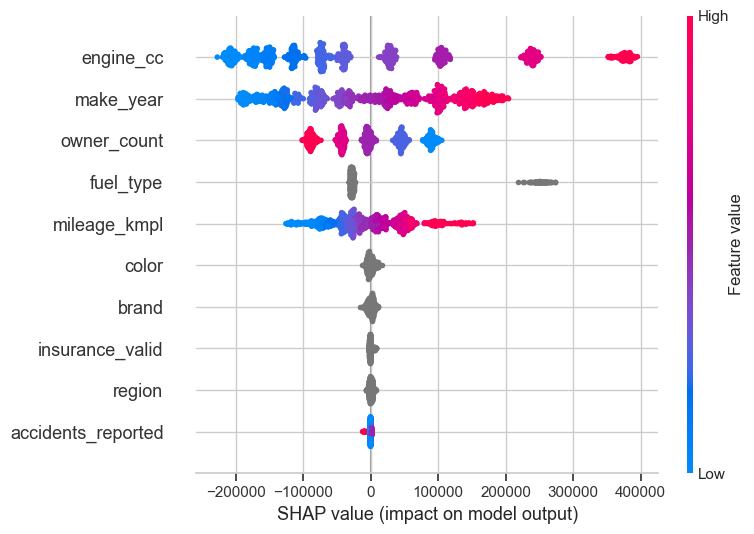

SHAP summary plot: xgb_optuna


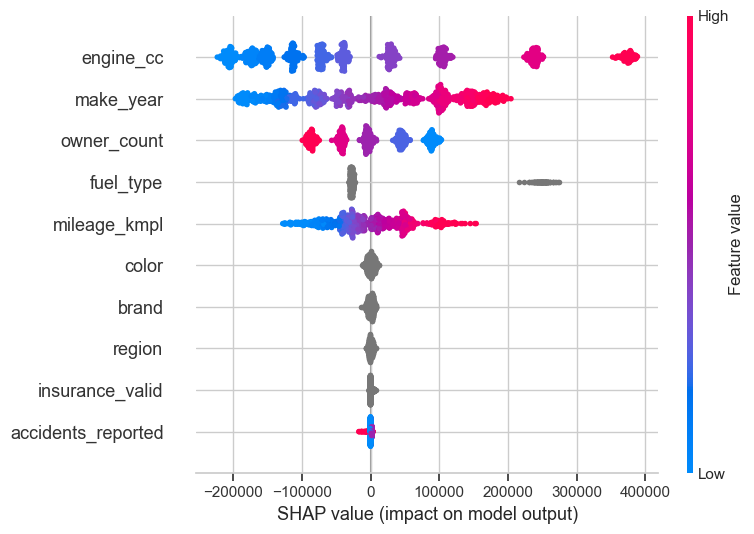

In [40]:
for name, model in optuna_models.items():
    print("=" * 80)
    print(f"SHAP summary plot: {name}")
    print("=" * 80)

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    if name == "cat_optuna":
        shap_values = fitted_model.get_feature_importance(
            Pool(X_shap, cat_features=cat_cols),
            type="ShapValues"
        )[:, :-1]

    else:
        explainer = shap.TreeExplainer(fitted_model)
        shap_values = explainer.shap_values(X_shap)

        if isinstance(shap_values, list):
            shap_values = shap_values[0]

    shap.summary_plot(
        shap_values,
        X_shap,
        max_display=10,
        show=True
    )

**Вывод по интерпретируемости:** топ-5 факторов стоимости стабилен во всех настроенных моделях: `engine_cc`, `make_year`, `owner_count`, `fuel_type`, `mileage_kmpl`. Это соответствует бизнес-логике рынка автомобилей: мощность/объем двигателя, возраст, тип топлива, число владельцев и пробег напрямую связаны с ценой. Неожиданных доминирующих признаков не видно: слабые EDA-признаки вроде `region` и `brand` не попали в топ SHAP, поэтому риск, что модель держится на случайных региональных или брендовых перекосах, выглядит ограниченным.


In [43]:
def group_pricing_analysis(model, X, y, group_col, threshold=0.20):
    preds = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        n_jobs=-1
    )

    group_df = X[[group_col]].copy()
    group_df["y_true"] = np.array(y)
    group_df["pred"] = preds
    group_df["error_ratio"] = (
        group_df["pred"] - group_df["y_true"]
    ) / group_df["y_true"]

    group_df["overpricing"] = group_df["error_ratio"] > threshold
    group_df["underpricing"] = group_df["error_ratio"] < -threshold
    group_df["underpricing_loss"] = np.where(
        group_df["underpricing"],
        group_df["y_true"] - group_df["pred"],
        0
    )

    result = (
        group_df
        .groupby(group_col, observed=False)
        .agg(
            count=("y_true", "size"),
            overpricing_rate=("overpricing", "mean"),
            underpricing_rate=("underpricing", "mean"),
            underpricing_loss=("underpricing_loss", "sum"),
            mean_error_ratio=("error_ratio", "mean"),
        )
        .reset_index()
    )

    result["overpricing_rate"] *= 100
    result["underpricing_rate"] *= 100

    return result.sort_values(
        ["overpricing_rate", "underpricing_loss"],
        ascending=False
    )


display(group_pricing_analysis(optuna_models["cat_optuna_quantile"], X_train, y_train, "brand").head(10))
display(group_pricing_analysis(optuna_models["cat_optuna_quantile"], X_train, y_train, "region").head(10))

,brand,count,overpricing_rate,underpricing_rate,underpricing_loss,mean_error_ratio
8,Toyota,792,11.36,11.87,"15,435,388.63",-0.01
2,Ford,742,11.05,9.03,"11,839,966.67",-0.00
5,Kia,765,10.85,10.72,"14,428,621.56",-0.00
4,Hyundai,785,10.57,9.55,"12,536,529.43",-0.00
9,Volkswagen,831,10.23,9.15,"13,309,020.82",-0.01
7,Tesla,784,9.82,8.67,"11,468,567.07",-0.00
6,Nissan,870,9.54,10.00,"14,871,387.20",-0.00
1,Chevrolet,800,9.12,9.38,"12,340,892.39",-0.00
0,BMW,827,9.07,12.33,"16,600,608.13",-0.01
3,Honda,804,8.46,9.08,"12,036,228.20",-0.01


,region,count,overpricing_rate,underpricing_rate,underpricing_loss,mean_error_ratio
4,Урал,1371,10.94,9.99,"22,805,937.48",0.00
5,Юг,1408,10.80,9.66,"23,104,346.95",-0.00
2,СПб,1346,10.10,10.33,"22,601,911.57",-0.01
0,Дальний Восток,1295,10.04,10.27,"23,410,915.96",-0.01
3,Сибирь,1261,9.36,9.20,"18,908,791.70",-0.01
1,Москва,1319,8.57,10.46,"24,035,306.42",-0.01


**Вывод по overpricing/underpricing:** для выбранной quantile-модели повышенный риск завышения виден у Toyota, Ford и Kia; среди регионов выше остальных Урал и Юг. По занижению цены выделяется BMW по доле underpricing и Москва по суммарному Underpricing Loss. Для AutoValue AI завышение цены опаснее как прямой риск купить автомобиль дороже рынка


In [44]:
final_model = optuna_models["cat_optuna_quantile"]

CatBoostRegressor(cat_features=('brand', 'color', 'fuel_type', 'insurance_valid', 'region', 'service_history', 'transmission'), depth=3, eval_metric='MAE', iterations=1154, l2_leaf_reg=6.680570270177146, learning_rate=0.024125471099492743, loss_function='Quantile:alpha=0.4', random_seed=42, verbose=0)

**Финальный выбор для test:** на финальную проверку выносится `cat_optuna_quantile`. Это не модель с минимальным MAE на validation, а более осторожный вариант CatBoost с меньшей долей опасных завышений цены. Такой выбор согласуется с бизнес-задачей автоматического выкупа, где переплата за автомобиль может быть дороже небольшого ухудшения средней ошибки.


In [45]:
X_test = test.drop(columns=[target])
y_test = test[target]

final_model.fit(X_train, y_train)
test_preds = final_model.predict(X_test)

test_result = pd.DataFrame({
    "Model": ["final_model_test"],
    "MAE": [mean_absolute_error(y_test, test_preds)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, test_preds))],
    "R2": [r2_score(y_test, test_preds)],
})

error_ratio = (test_preds - np.array(y_test)) / np.array(y_test)
under_mask = error_ratio < -0.20

test_result["Overpricing Rate, %"] = np.mean(error_ratio > 0.20) * 100
test_result["Underpricing Loss, руб."] = np.sum(
    np.array(y_test)[under_mask] - test_preds[under_mask]
)

display(test_result)

,Model,MAE,RMSE,R2,"Overpricing Rate, %","Underpricing Loss, руб."
0,final_model_test,"77,322.41","97,201.99",0.87,10.35,"33,454,074.94"


## Итоговый вывод для Артёма и Юли

**1. Что показал турнир моделей**

В турнире сравнивались CatBoost, LightGBM и XGBoost. По стандартным метрикам качества лучший результат дала библиотека **CatBoost**: после настройки Optuna модель `cat_optuna` получила MAE 76 410 руб., RMSE 95 961 руб. и R² 0.87 на кросс-валидации. Это означает, что средняя абсолютная ошибка оценки автомобиля составляет около 76 тыс. руб., а модель объясняет большую часть вариативности цены в данных.

LightGBM и XGBoost после настройки стали близки к CatBoost, но не обогнали его: `xgb_optuna` получил MAE 77 375 руб., `lgbm_optuna` — 77 426 руб. Разница по средней ошибке небольшая, но CatBoost дополнительно удобен для этого проекта, потому что стабильно работает с категориальными признаками автомобиля: брендом, регионом, типом топлива, сервисной историей и трансмиссией.


**2. Какую модель выбирать в разных бизнес-сценариях**

Если цель — **максимальная точность оценки**, лучше выбирать `cat_optuna`. Это самая точная модель на validation: MAE 76 410 руб., RMSE 95 961 руб., R² 0.87. Она подходит для аналитического сценария, внутренней оценки портфеля или ситуации, где одинаково важны завышения и занижения цены.

Если цель — **снизить риск переплаты при автоматическом выкупе**, лучше выбирать `cat_optuna_quantile`. У нее MAE выше — 78 824 руб. на validation, но Overpricing Rate ниже: 9.99% против 13.69% у `cat_optuna`. То есть модель немного жертвует средней точностью, зато заметно реже предлагает слишком высокую цену.

Если бизнес хочет **более агрессивно избегать завышений**, можно смотреть на CatBoost Quantile с меньшим `alpha`, например `cat_quantile_0.3`, где Overpricing Rate падает до 7.46%. Но такой вариант уже слишком сильно увеличивает Underpricing Loss до 225.4 млн руб.

LightGBM и XGBoost можно рассматривать как резервные варианты, но не как основной выбор. XGBoost быстро обучается и после Optuna почти догоняет LightGBM, но не дает лучшего баланса бизнес-метрик. LightGBM тоже показывает достойное качество, однако по итоговой таблице не превосходит CatBoost ни по MAE, ни по Overpricing Rate.

**4. Финальная рекомендация для внедрения**

Для мобильного приложения AutoValue AI рекомендуется внедрять **CatBoostRegressor с quantile-loss**, модель `cat_optuna_quantile`.

Гиперпараметры выбранной модели:

- `loss_function='Quantile:alpha=0.4'`
- `iterations=1154`
- `learning_rate=0.0241`
- `depth=3`
- `l2_leaf_reg=6.68`
- `random_seed=42`

Причина выбора: это лучший бизнес-компромисс между точностью и безопасностью. Модель немного уступает самой точной CatBoost-модели по MAE, но снижает долю опасных завышений цены примерно с 13.69% до 9.99% на validation. Для автоматического выкупа это важнее, чем минимальное улучшение средней ошибки.

**5. Проверка на финальном test**

На финальной тестовой выборке выбранная модель показала MAE 77 322 руб., RMSE 97 202 руб., R² 0.87 и Overpricing Rate 10.35%. Эти значения близки к validation-результатам: сильного ухудшения на отложенном test не видно. Это хороший признак стабильности модели и аргумент в пользу того, что она не переобучилась на train-validation цикле.

Underpricing Loss на test составил 33.45 млн руб. Важно учитывать, что test меньше validation-оценки по числу строк, поэтому суммарные рублевые потери напрямую сравнивать нельзя. Для мониторинга после запуска лучше отслеживать не только сумму потерь, но и долю сильных занижений, среднюю ошибку в рублях и распределение ошибок по брендам и регионам.

**6. Риски после запуска**

Даже выбранная модель не убирает риск полностью: около 10% тестовых объектов все еще имеют завышение больше 20%. Повышенное внимание нужно уделить Toyota, Ford и Kia, а также регионам Урал и Юг, где в анализе ошибок риск завышения был выше. По занижению цены стоит отдельно мониторить BMW и Москву, потому что там заметнее риск потери потенциальных сделок.

**Финальный вердикт:** для первого production-внедрения стоит выбрать **CatBoost Quantile (`cat_optuna_quantile`)** как более безопасную модель для автоматического выкупа. `cat_optuna` можно оставить как контрольную точную модель для сравнения и A/B-мониторинга, но основной сценарий мобильного приложения должен опираться на quantile-версию, потому что она лучше защищает бизнес от переплаты за автомобили.
